<a href="https://colab.research.google.com/github/CristianRiascos/Alura-TelecomX-Parte2-Challenge/blob/master/Challenge3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# **Preparación de los Datos**

## Extracción del archivo tratado

In [2]:
data = pd.read_csv( 'datos_tratados.csv' )

## Eliminación de Columnas Irrelevantes

In [3]:
data.head(4)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Charges.Daily
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,Un Año,Yes,Cheque por Correo,65.6,593.30,2.19
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Mes a Mes,No,Cheque por Correo,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fibra Óptica,...,Yes,No,No,No,Mes a Mes,Yes,Cheque Electrónico,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,Sí,Yes,No,13,Yes,No,Fibra Óptica,...,Yes,No,Yes,Yes,Mes a Mes,Yes,Cheque Electrónico,98.0,1237.85,3.27


In [4]:
data.drop( columns=['customerID'], inplace=True )

## Enconde

In [5]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [6]:
# Seleccionar las columnas categóricas
categorical_columns = data.select_dtypes(exclude=['int64', 'float64']).columns
categorical_columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [7]:
# Crear transformador
transformer = make_column_transformer(
    ( OneHotEncoder(drop='first'), categorical_columns ),
    remainder='passthrough',
    sparse_threshold=0,
    force_int_remainder_cols=False
)

In [8]:
# Crear DataFrame
X_transformed = transformer.fit_transform(data)
encoded_df = pd.DataFrame(
    X_transformed,
    columns=transformer.get_feature_names_out()
)
encoded_df.head(4)

,onehotencoder__Churn_Yes,onehotencoder__gender_Male,onehotencoder__SeniorCitizen_Sí,onehotencoder__Partner_Yes,onehotencoder__Dependents_Yes,onehotencoder__PhoneService_Yes,onehotencoder__MultipleLines_No phone service,onehotencoder__MultipleLines_Yes,onehotencoder__InternetService_Fibra Óptica,onehotencoder__InternetService_No,...,onehotencoder__Contract_Mes a Mes,onehotencoder__Contract_Un Año,onehotencoder__PaperlessBilling_Yes,onehotencoder__PaymentMethod_Cheque por Correo,onehotencoder__PaymentMethod_Tarjeta de Crédito (Automático),onehotencoder__PaymentMethod_Transferencia Bancaria (Automático),remainder__tenure,remainder__Charges.Monthly,remainder__Charges.Total,remainder__Charges.Daily
0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,9.0,65.6,593.30,2.19
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,9.0,59.9,542.40,2.00
2,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,4.0,73.9,280.85,2.46
3,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,13.0,98.0,1237.85,3.27


## Balanceo de la variable Churn

In [9]:
import matplotlib.pyplot as plt

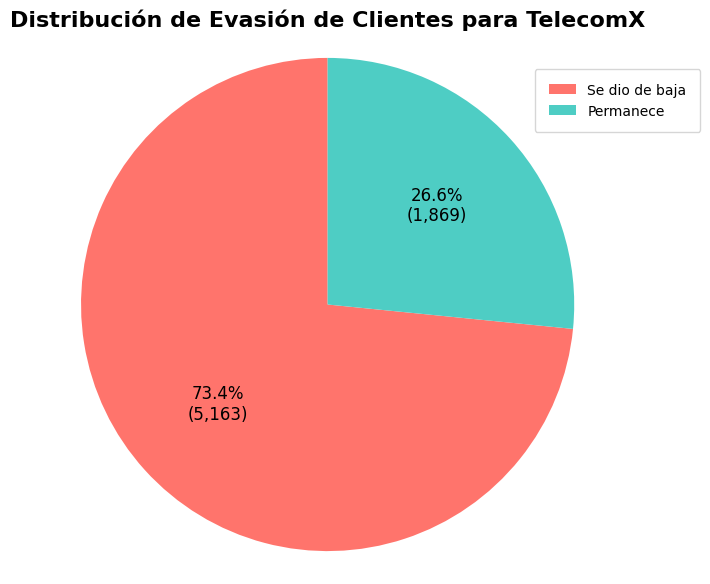

In [10]:
# Obtener el conteo de datos de la variable Churn
evasion = data['Churn'].value_counts()
total = sum(evasion.values)

# Cambiar a etiquetas más legibles para la leyenda
evasion.index = evasion.index.map({
    'Yes': 'Permanece',
    'No': 'Se dio de baja'
})

# Realizar el gráfico
plt.figure(figsize=(7, 7))
plt.pie( evasion.values,
         autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct * total / 100.0)):,})',
         textprops={'fontsize': 12},
         startangle=90,
         colors=['#FF746C', '#4ecdc4']
         )

# Modificar título y leyenda
plt.title( 'Distribución de Evasión de Clientes para TelecomX', fontsize=16, fontweight='bold' )
plt.axis('equal')
plt.legend( evasion.index,  loc='upper right', bbox_to_anchor=(1.20, 0.95), borderpad=1.0 )
plt.show()

# **Correlación y Selección de Variable**s

## Análisis de Correlación

In [11]:
import seaborn as sns
import numpy as np
import plotly.graph_objects as go

In [12]:
correlation = encoded_df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
correlation_masked = correlation.copy()
correlation_masked[mask] = np.nan

fig = go.Figure(data=go.Heatmap(
    z=correlation_masked.values,
    x=correlation_masked.columns,
    y=correlation_masked.index,
    colorscale='RdBu_r',
    zmid=0,
    colorbar=dict(title="Correlación"),
    hovertemplate='<b>%{y}</b> vs <b>%{x}</b><br>Correlación: <b>%{z:.3f}</b><extra></extra>'
))

fig.update_layout(
    title={
        'text': 'Mapa de Correlación de Variables',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18, 'weight': 'bold'}
    },
    width=1000,
    height=900,
    xaxis=dict(
        tickangle=-45,
        tickfont=dict(size=9)
    ),
    yaxis=dict(
        autorange='reversed',
        tickfont=dict(size=9)
    )
)

fig.show()

## Relación de variables respecto a la cancelación (Churn)

In [13]:
# Ordenar por correlación absoluta con Churn
sorted_cols = correlation['onehotencoder__Churn_Yes'].abs().sort_values(ascending=False).index.tolist()
corr_sorted = correlation.loc[sorted_cols, sorted_cols]

# Máscara triangular
mask = np.triu(np.ones_like(corr_sorted, dtype=bool))
corr_masked = corr_sorted.where(~mask)

# Texto anotaciones
text_vals = corr_masked.round(2).astype(str).replace('nan', '')

fig = go.Figure(go.Heatmap(
    z=corr_masked.values, x=corr_masked.columns, y=corr_masked.index,
    colorscale='RdBu_r', zmid=0, zmin=-1, zmax=1,
    colorbar=dict(title="Correlación"),
    hovertemplate='<b>%{y}</b> vs <b>%{x}</b><br>Correlación: <b>%{z:.3f}</b><extra></extra>'
))

churn_idx = sorted_cols.index('onehotencoder__Churn_Yes')
fig.add_shape(type='rect', line=dict(color='gold', width=2), fillcolor='rgba(0,0,0,0)',
              x0=-0.5, x1=churn_idx+0.5, y0=churn_idx-0.5, y1=churn_idx+0.5)

fig.update_layout(
   title={
        'text': 'Correlaciones respecto a Churn',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18, 'weight': 'bold'}
    },
    width=1100, height=1000,
    xaxis=dict(tickangle=-45, tickfont=dict(size=9)),
    yaxis=dict(autorange='reversed', tickfont=dict(size=9))
)

fig.show()